### Truncation Error

**Truncation error** adalah kesalahan yang terjadi karena deret Taylor yang sebenarnya memiliki jumlah suku tak hingga dipotong hanya sampai beberapa suku saja.

Deret Taylor dari suatu fungsi adalah:
$$f(x + Δx) = f(x) + Δx f'(x) + (1/2) Δx² f''(x) + (1/3!) Δx³ f'''(x) + ...$$

Dalam perhitungan numerik, biasanya hanya beberapa suku pertama yang digunakan.  
Suku-suku yang tidak dimasukkan inilah yang menyebabkan **truncation error**.

Materi ini menjelaskan bagaimana **kesalahan muncul saat menghitung turunan menggunakan metode beda hingga (finite difference)**.

Metode yang digunakan adalah **forward difference**:

$$D₊u(x) = (u(x + Δx) − u(x)) / Δx$$

Rumus ini digunakan untuk mendekati turunan pertama suatu fungsi.
___
#### Ekspansi Deret Taylor

##### Fungsi di titik x + Δx
$$
u(x + Δx) = u(x)  
+ Δx u'(x)  
+ (1/2) Δx² u''(x)  
+ (1/3!) Δx³ u'''(x)  
+ O(Δx⁴)
$$
Artinya nilai fungsi di titik sebelah kanan dapat didekati menggunakan nilai fungsi dan turunannya di titik x.

##### Fungsi di titik x − Δx
$$
u(x − Δx) = u(x)  
− Δx u'(x)  
+ (1/2) Δx² u''(x)  
− (1/3!) Δx³ u'''(x)  
+ O(Δx⁴)
$$
Perbedaannya hanya pada tanda positif dan negatif karena titiknya berada di sisi kiri.
___
#### substitusi ke Rumus Forward Difference

Rumus pendekatan turunan:

$$ D₊u(x) = (u(x + Δx) − u(x)) / Δx$$

Masukkan ekspansi Taylor:
$$
D₊u(x) = (Δx u'(x)  
+ (1/2) Δx² u''(x)  
+ (1/3!) Δx³ u'''(x)  
+ ...) / Δx
$$
Kemudian dibagi dengan Δx:
$$
D₊u(x) = u'(x)  
+ (1/2) Δx u''(x)  
+ (1/3!) Δx² u'''(x)  
+ O(Δx³)
$$

Jika kita menghitung selisih antara pendekatan turunan dan turunan sebenarnya:

$$D₊u(x) − u'(x)$$

maka kita mendapatkan truncation error:
$$
D₊u(x) − u'(x) =
(1/2) Δx u''(x) + (1/3!) Δx² u'''(x) + O(Δx³)
$$
Artinya:

Error utama berasal dari suku $(1/2) Δx u''(x)$

Sehingga besar error berorde $O(Δx)$

Ini berarti:

- Error sebanding dengan Δx
- Jika Δx diperkecil maka error juga semakin kecil

Error ini dipengaruhi oleh turunan kedua fungsi yaitu $u''(x)$.

Selain **forward difference**, ada metode lain yaitu **centered difference**.

Rumus centered difference:

$$D₀u(x) = (u(x+Δx) − u(x−Δx)) / (2Δx)$$

Jika dihitung truncation errornya:
$$
D₀u(x) − u'(x) =
(1/6) Δx² u'''(x) + O(Δx⁴)
$$
Artinya error utama berorde:
$$
O(Δx²)
$$
Ini berarti:

Centered difference lebih akurat daripada forward difference.

Perbandingan:

Forward difference → error $O(Δx)$

Centered difference → error $O(Δx²)$

Semakin tinggi orde $Δx$ maka metode tersebut semakin akurat.
___
##### Menghitung Order of Accuracy Secara Grafis

Untuk mengetahui tingkat akurasi metode numerik, error dapat dimodelkan sebagai:

$$e(Δx) = C Δxⁿ$$

dimana:

- $e(Δx)$ = error
- $C$ = konstanta
- $Δx$ = ukuran grid
- $n$ = order of accuracy
___
##### Menggunakan Logaritma

Agar lebih mudah dianalisis secara grafis, persamaan diubah menjadi bentuk logaritma:

$$log e(Δx) = log C + n log Δx$$

Ini membentuk persamaan garis lurus:

$$y = a + bx$$

dimana:

- $y$ = log error
- $x$ = log Δx
- $b$ = n (kemiringan garis)

Jika satu titik data diketahui, maka konstanta dapat dihitung dengan:

$$C = e^(log e(Δx) − n log Δx)$$

Konstanta ini digunakan untuk menyesuaikan model error dengan data numerik yang diperoleh.
___


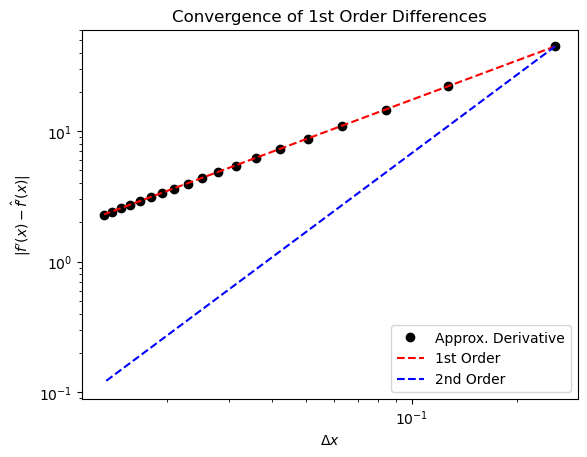

In [ ]:
# Import library yang diperlukan
import numpy
import matplotlib.pyplot as plt

f = lambda x: numpy.sin(x) + x**2 + 3.0 * x**3                # Mendefinisikan fungsi f(x) = sin(x) + x² + 3x³
f_prime = lambda x: numpy.cos(x) + 2.0 * x + 9.0 * x**2       # Turunan analitik f'(x) = cos(x) + 2x + 9x²

# Menghitung nilai error berdasarkan perubahan delta_x
delta_x = []                                                  # List untuk menyimpan nilai Δx (jarak antar grid)
error = []                                                    # List untuk menyimpan error turunan numerik

# for N in xrange(2, 101):
for N in range(50, 1000, 50):                                 # Mengubah jumlah titik grid dari 50 sampai 950
    x_hat = numpy.linspace(-2 * numpy.pi, 2 * numpy.pi, N)    # Membuat N titik dari -2π sampai 2π
    delta_x.append(x_hat[1] - x_hat[0])                       # Menghitung jarak antar titik (Δx)

    # Compute forward difference
    f_prime_hat = numpy.empty(x_hat.shape)                    # Array kosong untuk menyimpan turunan numerik
    f_prime_hat[:-1] = (f(x_hat[1:]) - f(x_hat[:-1])) / (delta_x[-1])  # Forward difference: (f(x+Δx)-f(x))/Δx

    # Use first-order differences for points at edge of domain
    f_prime_hat[-1] = (f(x_hat[-1]) - f(x_hat[-2])) / delta_x[-1]  # Backward difference untuk titik terakhir
    
    error.append(numpy.linalg.norm(numpy.abs(f_prime(x_hat + delta_x[-1]) - f_prime_hat), ord=numpy.inf))  # Menghitung error maksimum (norm infinity)
    
error = numpy.array(error)                                    # Mengubah list error menjadi array numpy
delta_x = numpy.array(delta_x)                                # Mengubah list Δx menjadi array numpy
    
fig = plt.figure()                                            # Membuat figure untuk grafik
axes = fig.add_subplot(1, 1, 1)                               # Membuat area plot

axes.loglog(delta_x, error, 'ko', label="Approx. Derivative")  # Plot log-log antara Δx dan error

order_C = lambda delta_x, error, order: numpy.exp(numpy.log(error) - order * numpy.log(delta_x))  # Fungsi untuk menghitung konstanta C pada model error

axes.loglog(delta_x, order_C(delta_x[0], error[0], 1.0) * delta_x**1.0, 'r--', label="1st Order") # Garis referensi error orde 1
axes.loglog(delta_x, order_C(delta_x[0], error[0], 2.0) * delta_x**2.0, 'b--', label="2nd Order") # Garis referensi error orde 2

axes.legend(loc=4)                                           # Menampilkan legenda di pojok kanan bawah
axes.set_title("Convergence of 1st Order Differences")       # Judul grafik
axes.set_xlabel(r"$\Delta x$")                               # Label sumbu x (ukuran grid)
axes.set_ylabel(r"$|f'(x) - \hat{f}'(x)|$")                  # Label sumbu y (besar error)

plt.show()                                                   # Menampilkan grafik

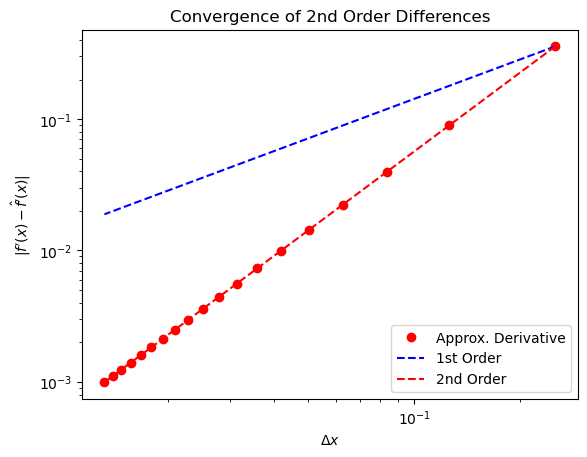

In [ ]:
import numpy                                                     # Library untuk komputasi numerik
import matplotlib.pyplot as plt                                  # Library untuk membuat grafik

# Mendefinisikan fungsi
f = lambda x: numpy.sin(x) + x**2 + 3.0 * x**3                   # Fungsi f(x)
f_prime = lambda x: numpy.cos(x) + 2.0 * x + 9.0 * x**2          # Turunan analitik f'(x)

# Menghitung nilai error berdasarkan perubahan delta_x
delta_x = []                                                     # Menyimpan nilai Δx
error = []                                                       # Menyimpan nilai error

for N in range(50, 1000, 50):                                    # Jumlah grid dari 50 sampai 950
    x_hat = numpy.linspace(-2 * numpy.pi, 2 * numpy.pi, N + 1)   # Membuat grid dari -2π sampai 2π
    delta_x.append(x_hat[1] - x_hat[0])                          # Menghitung Δx (jarak antar grid)

    # Array untuk menyimpan turunan numerik
    f_prime_hat = numpy.empty(x_hat.shape)

    # Central Difference (orde 2)
    # f'(x) ≈ (f(x+Δx) - f(x-Δx)) / (2Δx)
    f_prime_hat[1:-1] = (f(x_hat[2:]) - f(x_hat[:-2])) / (2 * delta_x[-1])

    # Turunan di batas domain menggunakan skema orde 2
    f_prime_hat[0] = (-3.0 * f(x_hat[0]) + 4.0 * f(x_hat[1]) - f(x_hat[2])) / (2.0 * delta_x[-1])
    f_prime_hat[-1] = (3.0 * f(x_hat[-1]) - 4.0 * f(x_hat[-2]) + f(x_hat[-3])) / (2.0 * delta_x[-1])

    # Menghitung error maksimum (infinity norm)
    error.append(numpy.linalg.norm(numpy.abs(f_prime(x_hat) - f_prime_hat), ord=numpy.inf))

# Mengubah list menjadi array numpy
error = numpy.array(error)
delta_x = numpy.array(delta_x)

# Membuat grafik
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)

# Plot error numerik
axes.loglog(delta_x, error, "ro", label="Approx. Derivative")

# Fungsi untuk menghitung konstanta C pada model error e(Δx) = CΔx^n
order_C = lambda delta_x, error, order: numpy.exp(numpy.log(error) - order * numpy.log(delta_x))

# Garis referensi orde akurasi
axes.loglog(delta_x, order_C(delta_x[0], error[0], 1.0) * delta_x**1.0, 'b--', label="1st Order")
axes.loglog(delta_x, order_C(delta_x[0], error[0], 2.0) * delta_x**2.0, 'r--', label="2nd Order")

# Pengaturan grafik
axes.legend(loc=4)
axes.set_title("Convergence of 2nd Order Differences")
axes.set_xlabel(r"$\Delta x$")                               # Raw string agar tidak warning
axes.set_ylabel(r"$|f'(x) - \hat{f}'(x)|$")                  # Raw string untuk format LaTeX

plt.show()

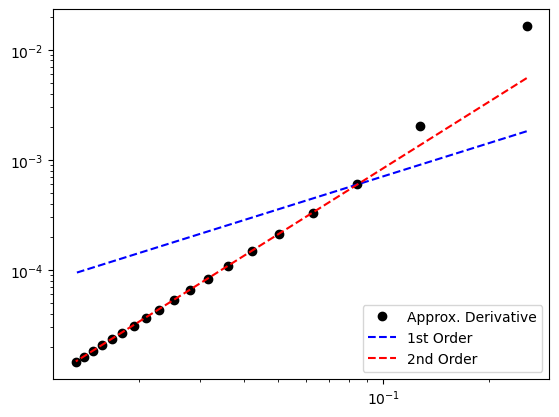

In [ ]:
import numpy                                                # Library komputasi numerik
import matplotlib.pyplot as plt                             # Library untuk membuat grafik

# Mendefinisikan fungsi
f = lambda x: numpy.sin(x) + x**2 + 3.0 * x**3              # Fungsi f(x)
f_dubl_prime = lambda x: -numpy.sin(x) + 2.0 + 18.0 * x     # Turunan kedua analitik f''(x)

# Menghitung nilai error berdasarkan perubahan delta_x
delta_x = []                                                # List untuk menyimpan nilai Δx
error = []                                                  # List untuk menyimpan nilai error

# for N in xrange(2, 101):
for N in range(50, 1000, 50):                               # Jumlah grid dari 50 sampai 950
    x_hat = numpy.linspace(-2 * numpy.pi, 2 * numpy.pi, N)  # Membuat grid dari -2π sampai 2π
    delta_x.append(x_hat[1] - x_hat[0])                     # Menghitung Δx (jarak antar grid)

    # Array untuk menyimpan hasil turunan numerik
    f_dubl_prime_hat = numpy.empty(x_hat.shape)

    # Menghitung turunan kedua menggunakan central difference
    # f''(x) ≈ (f(x+Δx) - 2f(x) + f(x-Δx)) / Δx²
    f_dubl_prime_hat[1:-1] = (f(x_hat[2:]) - 2.0 * f(x_hat[1:-1]) + f(x_hat[:-2])) / (delta_x[-1]**2)

    # Menggunakan skema beda hingga orde 2 untuk titik di batas domain
    f_dubl_prime_hat[0] = (2.0 * f(x_hat[0]) - 5.0 * f(x_hat[1]) + 4.0 * f(x_hat[2]) - f(x_hat[3])) / delta_x[-1]**2
    f_dubl_prime_hat[-1] = (2.0 * f(x_hat[-1]) - 5.0 * f(x_hat[-2]) + 4.0 * f(x_hat[-3]) - f(x_hat[-4])) / delta_x[-1]**2
    
    # Menghitung error maksimum antara turunan analitik dan turunan numerik
    error.append(numpy.linalg.norm(numpy.abs(f_dubl_prime(x_hat) - f_dubl_prime_hat), ord=numpy.inf))

# Mengubah list menjadi array numpy
error = numpy.array(error)
delta_x = numpy.array(delta_x)

# Membuat grafik
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)

# Plot error
axes.loglog(delta_x, error, "ko", label="Approx. Derivative")

# Fungsi untuk menentukan konstanta C pada model error e(Δx) = CΔx^n
order_C = lambda delta_x, error, order: numpy.exp(numpy.log(error) - order * numpy.log(delta_x))

# Garis referensi orde akurasi
axes.loglog(delta_x, order_C(delta_x[2], error[2], 1.0) * delta_x**1.0, 'b--', label="1st Order")
axes.loglog(delta_x, order_C(delta_x[2], error[2], 2.0) * delta_x**2.0, 'r--', label="2nd Order")

axes.legend(loc=4)                                             # Menampilkan legenda grafik

plt.show()                                                     # Menampilkan grafik